## 03 Embedding Benchmark

This notebook benchmarks lexical and embedding-based similarity methods for curriculum overlap detection on the JAMK ICT course-pair dataset.

### Main goal

The purpose of Notebook 03 is to evaluate **score quality** and **representation quality**, not final threshold decisions.

It answers:

> Which embedding model, text representation, and similarity metric combination produces similarity scores that best separate meaningful overlap pairs from non-overlap pairs?

### What this notebook does

- loads the cleaned course dataset from Notebook 01
- loads the fully labeled pair dataset from Notebook 02
- validates the extreme class imbalance explicitly
- creates a fixed **course-level** dev/test split
- discards mixed pairs where one course is in dev and the other is in test
- benchmarks:
  - TF-IDF baseline
  - OpenAI `text-embedding-3-large`
  - `intfloat/multilingual-e5-base`
  - `intfloat/multilingual-e5-large`
  - `BAAI/bge-m3`
- compares two text variants:
  - `embedding_text_main`
  - `embedding_text_enriched`
- compares two similarity metrics:
  - cosine similarity
  - dot product
- evaluates ranking quality primarily on the **development split**
- saves benchmark tables and figures for Notebook 04

### What this notebook does not do

- it does not choose the final production threshold
- it does not finalize the classifier decision rule
- it does not rebalance the naturally imbalanced dataset
- it does not treat accuracy as the main benchmark metric

### Important methodological note

The labeled dataset is strongly imbalanced because meaningful curriculum overlap is rare in the real course set.  
If there are only 27 positive pairs out of 1225, then the positive rate is approximately 2.2%.

For that reason, **raw accuracy is not a meaningful headline metric** in this notebook.

The primary focus is on:

- Average Precision / PR-AUC
- ROC-AUC as a secondary ranking metric
- score separation between positives and negatives
- qualitative inspection of top-ranked pairs and hard false positives

### Split design

This notebook uses a **course-level split** rather than a pair-level split.

That means:
- a course is assigned either to dev or to test
- a pair is assigned to dev only if both courses are in dev
- a pair is assigned to test only if both courses are in test
- mixed pairs are excluded from benchmark evaluation

This is more conservative than a pair-level split and provides a more honest held-out evaluation.

### Similarity metric note

This notebook evaluates **both cosine similarity and dot product**.

For dense embedding models, cosine and dot are only meaningfully different if both:
- raw embeddings are preserved for dot-product scoring
- L2-normalized embeddings are used for cosine scoring

This notebook therefore keeps separate score paths for cosine and dot when needed.

In [9]:
# Cell 01 - Import libraries and define project paths

from pathlib import Path
import os
import time
import random
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from dotenv import load_dotenv

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

from sentence_transformers import SentenceTransformer
from openai import OpenAI

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "benchmark"
TABLES_DIR = REPORTS_DIR / "tables" / "benchmark"
EMBEDDINGS_DIR = DATA_DIR / "embeddings"
BENCHMARK_PAIRS_DIR = DATA_DIR / "benchmark_pairs"
SPLITS_DIR = DATA_DIR / "splits"

COURSES_CSV_PATH = DATA_DIR / "courses_clean.csv"
PAIRS_CSV_PATH = DATA_DIR / "gold_pairs_review_labeled.csv"
ENV_PATH = PROJECT_ROOT / ".env"

COURSE_SPLIT_CSV_PATH = SPLITS_DIR / "course_dev_test_split.csv"
PAIR_SPLIT_CSV_PATH = SPLITS_DIR / "pair_dev_test_split_course_level.csv"

PAIR_SCORES_CSV_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.csv"
PAIR_SCORES_PARQUET_PATH = BENCHMARK_PAIRS_DIR / "pair_similarity_scores_long.parquet"
EMBEDDING_INVENTORY_CSV_PATH = EMBEDDINGS_DIR / "embedding_inventory.csv"

DEV_SUMMARY_CSV_PATH = TABLES_DIR / "benchmark_summary_dev.csv"
LEADERBOARD_CSV_PATH = TABLES_DIR / "benchmark_leaderboard_dev.csv"
TOP_PAIRS_CSV_PATH = TABLES_DIR / "top_ranked_dev_pairs_by_config.csv"
HARD_FALSE_POSITIVES_CSV_PATH = TABLES_DIR / "hard_false_positives_dev_top5_by_config.csv"
SHORTLIST_CSV_PATH = TABLES_DIR / "shortlist_for_notebook_04.csv"

for path in [FIGURES_DIR, TABLES_DIR, EMBEDDINGS_DIR, BENCHMARK_PAIRS_DIR, SPLITS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TEST_COURSE_FRACTION = 0.30
COURSE_SPLIT_SEARCH_TRIALS = 15000

TARGET_MIN_TEST_POSITIVES = 5
FALLBACK_MIN_TEST_POSITIVES = 4
MIN_DEV_POSITIVES = 18

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Project root:", PROJECT_ROOT)
print("Courses CSV:", COURSES_CSV_PATH)
print("Pairs CSV:", PAIRS_CSV_PATH)
print("Environment file:", ENV_PATH)
print("Figures dir:", FIGURES_DIR)
print("Tables dir:", TABLES_DIR)
print("Embeddings dir:", EMBEDDINGS_DIR)
print("Benchmark pairs dir:", BENCHMARK_PAIRS_DIR)
print("Splits dir:", SPLITS_DIR)
print("CUDA available:", torch.cuda.is_available())

Project root: C:\Users\user\Downloads\curriculum-overlap-poc
Courses CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\courses_clean.csv
Pairs CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\gold_pairs_review_labeled.csv
Environment file: C:\Users\user\Downloads\curriculum-overlap-poc\.env
Figures dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\figures\benchmark
Tables dir: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark
Embeddings dir: C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings
Benchmark pairs dir: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs
Splits dir: C:\Users\user\Downloads\curriculum-overlap-poc\data\splits
CUDA available: False


### Environment setup

This notebook supports both:

- local open-source embedding models
- OpenAI embedding API evaluation

Expected `.env` file location:

`curriculum-overlap-poc/.env`

Expected variable:

- `OPENAI_API_KEY`

In [10]:
# Cell 02 - Load environment variables and initialize OpenAI client if available

load_dotenv(ENV_PATH)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()

openai_client = None
if OPENAI_API_KEY:
    openai_client = OpenAI(api_key=OPENAI_API_KEY)
    print("OpenAI API key loaded: Yes")
else:
    print("OpenAI API key loaded: No")

USE_OPENAI_MODEL = bool(OPENAI_API_KEY)
print("Use OpenAI benchmark:", USE_OPENAI_MODEL)

OpenAI API key loaded: Yes
Use OpenAI benchmark: True


### Load datasets

This notebook uses:

- `courses_clean.csv` from Notebook 01
- `gold_pairs_review_labeled.csv` from Notebook 02

In [11]:
# Cell 03 - Load datasets

courses_df = pd.read_csv(COURSES_CSV_PATH, encoding="utf-8", keep_default_na=False)
pairs_df = pd.read_csv(PAIRS_CSV_PATH, encoding="utf-8", keep_default_na=False)

print("courses_df shape:", courses_df.shape)
print("pairs_df shape:", pairs_df.shape)

display(courses_df.head(2))
display(pairs_df.head(2))

courses_df shape: (50, 24)
pairs_df shape: (1225, 10)


,degree_programme,course_name,course_unit_code,credits,teaching_language_text,responsible_person_text,objective_text,competences_knowledge_text,competences_practice_text,competences_applying_technology_text,competences_multidisciplinary_text,competences_communication_text,competences_investigations_text,learning_outcomes_text,content_text,prerequisites_text,assessment_grading_scale,assessment_pass_fail_criteria,course_name_normalized,prerequisites_text_normalized,embedding_text_main,embedding_text_enriched,review_text_compact,review_text_full
0,Information and Communication Technology,Data Networks,TT00CD70,5,"Finnish, English",Pasi Hyytiäinen,You learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data network. You are ...,You know the main modeling methods of data networks. You have knowledge and understanding of data networks and their effects. You know the basic principles ...,You can apply data network skills to communication between devices.,,,,,,"In this course, you will learn the principles of network structure and protocol design, as well as the principles of Internet communication. You will master...",Linux Basics,1-5,The student has sufficient knowledge of the theory on network protocols and is able to recognize some sections of existing solutions. The student can design...,data networks,linux basics,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Course code: TT00CD70\nCourse name: Data Networks\nObjective: You learn the structure and protocols of data networks used by computers and other end devices...,Course code: TT00CD70\nCourse name: Data Networks\nObjective: You learn the structure and protocols of data networks used by computers and other end devices...
1,Information and Communication Technology,Linux Basics,TT00CD71,4,"Finnish, English","Juho Pekki, Teemu Siikaniemi","After completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work with and manage t...",You understand the key concepts and architecture of the Linux operating system. You understand the importance of managing user accounts and groups.,You know how to manage the key functions of the Linux system and use command-line tools. You know how to manage the filesystem and user account permissions....,,,,,,"In this course, you will learn how to effectively manage the Linux operating system using a text-based interface. You will understand key concepts and be ab...",,1-5,,linux basics,,"Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Course code: TT00CD71\nCourse name: Linux Basics\nObjective: After completing the course, you will understand the most important concepts of the Linux opera...","Course code: TT00CD71\nCourse name: Linux Basics\nObjective: After completing the course, you will understand the most important concepts of the Linux opera..."


,pair_id,course_unit_code_1,course_name_1,review_text_1,course_unit_code_2,course_name_2,review_text_2,overlap_label,review_status,review_notes
0,TT00CD70__TT00CD71,TT00CD70,Data Networks,Course code: TT00CD70 | Course name: Data Networks | Objective: You learn the structure and protocols of data networks used by computers and other end devic...,TT00CD71,Linux Basics,"Course code: TT00CD71 | Course name: Linux Basics | Objective: After completing the course, you will understand the most important concepts of the Linux ope...",0,reviewed,
1,TT00CD70__TT00CD72,TT00CD70,Data Networks,Course code: TT00CD70 | Course name: Data Networks | Objective: You learn the structure and protocols of data networks used by computers and other end devic...,TT00CD72,Servers and containers,Course code: TT00CD72 | Course name: Servers and containers | Objective: You understand the fundamental types and functions of servers. You understand the k...,0,reviewed,


In [12]:
# Cell 04 - Validate required columns

required_course_columns = [
    "course_unit_code",
    "course_name",
    "embedding_text_main",
    "embedding_text_enriched",
    "review_text_full",
]

required_pair_columns = [
    "pair_id",
    "course_unit_code_1",
    "course_name_1",
    "course_unit_code_2",
    "course_name_2",
    "overlap_label",
    "review_status",
    "review_notes",
]

missing_course_columns = [col for col in required_course_columns if col not in courses_df.columns]
missing_pair_columns = [col for col in required_pair_columns if col not in pairs_df.columns]

if missing_course_columns:
    raise ValueError(f"Missing required course columns: {missing_course_columns}")

if missing_pair_columns:
    raise ValueError(f"Missing required pair columns: {missing_pair_columns}")

if courses_df["course_unit_code"].duplicated().any():
    raise ValueError("Duplicate course_unit_code values found in courses_df.")

if pairs_df["pair_id"].duplicated().any():
    raise ValueError("Duplicate pair_id values found in pairs_df.")

print("All required columns are present.")

All required columns are present.


In [13]:
# Cell 05 - Normalize labels and review status

def normalize_overlap_label(value):
    text = str(value).strip().lower()
    if text in {"1", "true", "yes", "overlap"}:
        return 1
    if text in {"0", "false", "no", "none", "no overlap"}:
        return 0
    return np.nan

pairs_df["overlap_label_binary"] = pairs_df["overlap_label"].apply(normalize_overlap_label)
pairs_df["review_status_normalized"] = pairs_df["review_status"].astype(str).str.strip().str.lower()

invalid_label_count = pairs_df["overlap_label_binary"].isna().sum()
if invalid_label_count > 0:
    raise ValueError(f"Found {invalid_label_count} invalid overlap_label values.")

reviewed_count = (pairs_df["review_status_normalized"] == "reviewed").sum()

print("Rows with valid binary label:", len(pairs_df))
print("Reviewed rows:", reviewed_count)
print("Positive labels:", int(pairs_df["overlap_label_binary"].sum()))
print("Negative labels:", int((pairs_df["overlap_label_binary"] == 0).sum()))

display(pairs_df["overlap_label_binary"].value_counts().sort_index())

Rows with valid binary label: 1225
Reviewed rows: 1225
Positive labels: 27
Negative labels: 1198


overlap_label_binary
0    1198
1      27
Name: count, dtype: int64

In [15]:
# Cell 06 - Class imbalance audit

total_pairs = len(pairs_df)
positive_pairs = int(pairs_df["overlap_label_binary"].sum())
negative_pairs = int((pairs_df["overlap_label_binary"] == 0).sum())
positive_rate = positive_pairs / total_pairs

imbalance_summary = pd.Series({
    "total_pairs": total_pairs,
    "positive_pairs": positive_pairs,
    "negative_pairs": negative_pairs,
    "positive_rate": round(positive_rate, 6),
    "negative_to_positive_ratio": round(negative_pairs / positive_pairs, 2) if positive_pairs > 0 else np.nan,
})

display(imbalance_summary)

print()
print("Interpretation:")
print(
    "This is a highly imbalanced ranking problem. "
    "Average Precision and PR-based interpretation are more informative than raw accuracy."
)

total_pairs                   1225.000000
positive_pairs                  27.000000
negative_pairs                1198.000000
positive_rate                    0.022041
negative_to_positive_ratio      44.370000
dtype: float64


Interpretation:
This is a highly imbalanced ranking problem. Average Precision and PR-based interpretation are more informative than raw accuracy.


### Create a fixed course-level dev/test split

This notebook uses a **course-level split** rather than splitting pairs directly.

A pair is assigned:
- `dev` if both courses belong to the dev course set
- `test` if both courses belong to the test course set
- `mixed_discard` if one course is in dev and the other is in test

Mixed pairs are excluded from benchmark evaluation.

#### Important note about split construction

Because the labeled dataset is small and positive overlap pairs are rare, the notebook uses a constrained deterministic search to find a **course-level split that preserves a minimally usable number of positive pairs in both dev and test**.

This improves practical usability for Notebook 03 and Notebook 04, but it is not the same as a completely arbitrary single split. That should be acknowledged as a methodological limitation in the thesis.

In [16]:
# Cell 07 - Search for a course-level split that preserves usable positive pairs

all_course_codes = sorted(courses_df["course_unit_code"].tolist())
n_courses = len(all_course_codes)
n_test_courses = int(round(n_courses * TEST_COURSE_FRACTION))

positive_pairs_df = pairs_df[pairs_df["overlap_label_binary"] == 1].copy()

best_result = None

for trial in range(COURSE_SPLIT_SEARCH_TRIALS):
    rng = random.Random(RANDOM_SEED + trial)
    test_courses = set(rng.sample(all_course_codes, n_test_courses))
    dev_courses = set(all_course_codes) - test_courses

    pair_split_labels = []
    for _, row in pairs_df.iterrows():
        c1 = row["course_unit_code_1"]
        c2 = row["course_unit_code_2"]

        if c1 in dev_courses and c2 in dev_courses:
            pair_split_labels.append("dev")
        elif c1 in test_courses and c2 in test_courses:
            pair_split_labels.append("test")
        else:
            pair_split_labels.append("mixed_discard")

    temp_df = pairs_df[["pair_id", "overlap_label_binary"]].copy()
    temp_df["split"] = pair_split_labels

    dev_pos = int(temp_df.loc[(temp_df["split"] == "dev") & (temp_df["overlap_label_binary"] == 1)].shape[0])
    test_pos = int(temp_df.loc[(temp_df["split"] == "test") & (temp_df["overlap_label_binary"] == 1)].shape[0])
    dev_pairs = int((temp_df["split"] == "dev").sum())
    test_pairs = int((temp_df["split"] == "test").sum())
    usable_pairs = dev_pairs + test_pairs
    mixed_discard_pairs = int((temp_df["split"] == "mixed_discard").sum())
    kept_positives = dev_pos + test_pos

    feasible_target = (dev_pos >= MIN_DEV_POSITIVES) and (test_pos >= TARGET_MIN_TEST_POSITIVES) and (test_pairs > 0)
    feasible_fallback = (dev_pos >= MIN_DEV_POSITIVES) and (test_pos >= FALLBACK_MIN_TEST_POSITIVES) and (test_pairs > 0)

    candidate = {
        "trial": trial,
        "dev_courses": sorted(dev_courses),
        "test_courses": sorted(test_courses),
        "dev_pairs": dev_pairs,
        "test_pairs": test_pairs,
        "usable_pairs": usable_pairs,
        "mixed_discard_pairs": mixed_discard_pairs,
        "dev_positives": dev_pos,
        "test_positives": test_pos,
        "kept_positives": kept_positives,
        "discarded_positives": int(positive_pairs_df.shape[0] - kept_positives),
        "feasible_target": feasible_target,
        "feasible_fallback": feasible_fallback,
    }

    if best_result is None:
        best_result = candidate
    else:
        current_key = (
            candidate["feasible_target"],
            candidate["feasible_fallback"],
            candidate["kept_positives"],
            candidate["test_positives"],
            candidate["dev_positives"],
            candidate["usable_pairs"],
            -abs(candidate["test_pairs"] - 105),
        )
        best_key = (
            best_result["feasible_target"],
            best_result["feasible_fallback"],
            best_result["kept_positives"],
            best_result["test_positives"],
            best_result["dev_positives"],
            best_result["usable_pairs"],
            -abs(best_result["test_pairs"] - 105),
        )

        if current_key > best_key:
            best_result = candidate

if best_result is None:
    raise ValueError("Failed to construct a course-level split.")

if best_result["feasible_target"]:
    split_selection_status = f"Target achieved: at least {TARGET_MIN_TEST_POSITIVES} test positives."
elif best_result["feasible_fallback"]:
    split_selection_status = (
        f"Fallback used: target of {TARGET_MIN_TEST_POSITIVES} test positives not found, "
        f"but at least {FALLBACK_MIN_TEST_POSITIVES} test positives was achieved."
    )
else:
    raise ValueError(
        "No feasible course-level split found that satisfies the minimum positive-pair requirements."
    )

split_summary_series = pd.Series({
    "split_selection_status": split_selection_status,
    "feasible_target": best_result["feasible_target"],
    "feasible_fallback": best_result["feasible_fallback"],
    "dev_pairs": best_result["dev_pairs"],
    "test_pairs": best_result["test_pairs"],
    "usable_pairs": best_result["usable_pairs"],
    "mixed_discard_pairs": best_result["mixed_discard_pairs"],
    "dev_positives": best_result["dev_positives"],
    "test_positives": best_result["test_positives"],
    "kept_positives": best_result["kept_positives"],
    "discarded_positives": best_result["discarded_positives"],
})

print("Best course-level split found:")
display(split_summary_series)

print()
print("Interpretation:")
print(
    "This split was chosen to preserve a workable number of positives in both development and test. "
    "It is more defensible than a pair-level split, but it is still a constrained split search rather than a fully arbitrary single holdout."
)

Best course-level split found:


split_selection_status    Target achieved: at least 5 test positives.
feasible_target                                                  True
feasible_fallback                                                True
dev_pairs                                                         595
test_pairs                                                        105
usable_pairs                                                      700
mixed_discard_pairs                                               525
dev_positives                                                      20
test_positives                                                      5
kept_positives                                                     25
discarded_positives                                                 2
dtype: object


Interpretation:
This split was chosen to preserve a workable number of positives in both development and test. It is more defensible than a pair-level split, but it is still a constrained split search rather than a fully arbitrary single holdout.


In [17]:
# Cell 08 - Save course-level split and assign pair splits

course_split_df = pd.DataFrame({
    "course_unit_code": all_course_codes,
})
course_split_df["split"] = np.where(
    course_split_df["course_unit_code"].isin(best_result["test_courses"]),
    "test",
    "dev"
)

course_split_df.to_csv(COURSE_SPLIT_CSV_PATH, index=False, encoding="utf-8")

course_split_map = dict(zip(course_split_df["course_unit_code"], course_split_df["split"]))

pairs_df["course_split_1"] = pairs_df["course_unit_code_1"].map(course_split_map)
pairs_df["course_split_2"] = pairs_df["course_unit_code_2"].map(course_split_map)

def assign_pair_split(row):
    if row["course_split_1"] == "dev" and row["course_split_2"] == "dev":
        return "dev"
    if row["course_split_1"] == "test" and row["course_split_2"] == "test":
        return "test"
    return "mixed_discard"

pairs_df["split"] = pairs_df.apply(assign_pair_split, axis=1)

pairs_df[["pair_id", "split"]].to_csv(PAIR_SPLIT_CSV_PATH, index=False, encoding="utf-8")

print("Saved course split to:", COURSE_SPLIT_CSV_PATH)
print("Saved pair split to:", PAIR_SPLIT_CSV_PATH)

display(course_split_df["split"].value_counts())
display(
    pairs_df.groupby("split")["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
)

Saved course split to: C:\Users\user\Downloads\curriculum-overlap-poc\data\splits\course_dev_test_split.csv
Saved pair split to: C:\Users\user\Downloads\curriculum-overlap-poc\data\splits\pair_dev_test_split_course_level.csv


split
dev     35
test    15
Name: count, dtype: int64

,count,positive_count
split,,
dev,595,20
mixed_discard,525,2
test,105,5


In [18]:
# Cell 09 - Keep only usable benchmark pairs and show discarded positives

benchmark_pairs_df = pairs_df[pairs_df["split"].isin(["dev", "test"])].copy()

if benchmark_pairs_df.empty:
    raise ValueError("No usable benchmark pairs remain after course-level split.")

print("Usable benchmark pair counts:")
display(
    benchmark_pairs_df.groupby("split")["overlap_label_binary"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "positive_count"})
)

discarded_positive_pairs_df = pairs_df[
    (pairs_df["split"] == "mixed_discard") &
    (pairs_df["overlap_label_binary"] == 1)
][[
    "pair_id",
    "course_name_1",
    "course_name_2",
    "review_notes",
]].copy()

print("Discarded positive pairs:")
display(discarded_positive_pairs_df)

Usable benchmark pair counts:


,count,positive_count
split,,
dev,595,20
test,105,5


Discarded positive pairs:


,pair_id,course_name_1,course_name_2,review_notes
997,TT00CD98__TT00CE02,Mathematical Foundations of Machine Learning,Machine Learning: Regression Methods,"Both courses share core machine learning and statistical foundations. Mathematical Foundations of ML teaches probability, statistics, and linear algebra use..."
1054,TT00CE01__TT00CE02,Machine Learning: Classification Methods,Machine Learning: Regression Methods,"Both cover machine learning workflow fundamentals such as training, evaluation, and model performance analysis."


### Build the course-text dataframe

Each course is embedded once per model and text variant.
Those course embeddings are then reused to compute pairwise similarity scores.

In [19]:
# Cell 10 - Build course text dataframe for the locked Notebook 01 workflow

course_text_df = courses_df[[
    "course_unit_code",
    "course_name",
    "embedding_text_main",
    "embedding_text_enriched",
]].copy()

for col in ["embedding_text_main", "embedding_text_enriched"]:
    empty_count = (course_text_df[col].fillna("").astype(str).str.strip() == "").sum()
    print(f"Empty rows in {col}: {empty_count}")
    if empty_count > 0:
        raise ValueError(f"Found empty text rows in {col}.")

print("course_text_df shape:", course_text_df.shape)
display(course_text_df.head(3))

Empty rows in embedding_text_main: 0
Empty rows in embedding_text_enriched: 0
course_text_df shape: (50, 4)


,course_unit_code,course_name,embedding_text_main,embedding_text_enriched
0,TT00CD70,Data Networks,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...,Data Networks\nYou learn the structure and protocols of data networks used by computers and other end devices. You know the principles of planning a data ne...
1,TT00CD71,Linux Basics,"Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit...","Linux Basics\nAfter completing the course, you will understand the most important concepts of the Linux operating system (Linux OS) and know how to work wit..."
2,TT00CD72,Servers and containers,Servers and containers\nYou understand the fundamental types and functions of servers. You understand the key concepts of various services offered by cloud ...,Servers and containers\nYou understand the fundamental types and functions of servers. You understand the key concepts of various services offered by cloud ...


### Benchmark configurations

Text variants:
- `main`
- `enriched`

Models:
- TF-IDF baseline
- OpenAI `text-embedding-3-large`
- `intfloat/multilingual-e5-base`
- `intfloat/multilingual-e5-large`
- `BAAI/bge-m3`

Similarity metrics:
- cosine
- dot

For the multilingual E5 models, this notebook uses a consistent `query: ` prefix for both compared course texts. This is acceptable here because the task is symmetric course-course similarity and we want a stable representation format across compared texts.

For dense models:
- cosine similarity is computed from L2-normalized embeddings
- dot product is computed from raw embeddings

This ensures that cosine and dot are genuinely different comparison metrics when model vector magnitudes carry information.

In [20]:
# Cell 11 - Define benchmark configurations

TEXT_VARIANTS = {
    "main": "embedding_text_main",
    "enriched": "embedding_text_enriched",
}

SIMILARITY_METRICS = ["cosine", "dot"]

MODEL_CONFIGS = [
    {"model_name": "tfidf", "model_type": "tfidf", "hf_id": None, "openai_id": None},
    {"model_name": "openai_text-embedding-3-large", "model_type": "openai", "hf_id": None, "openai_id": "text-embedding-3-large"},
    {"model_name": "multilingual-e5-base", "model_type": "sentence_transformer", "hf_id": "intfloat/multilingual-e5-base", "openai_id": None},
    {"model_name": "multilingual-e5-large", "model_type": "sentence_transformer", "hf_id": "intfloat/multilingual-e5-large", "openai_id": None},
    {"model_name": "bge-m3", "model_type": "sentence_transformer", "hf_id": "BAAI/bge-m3", "openai_id": None},
]

if not USE_OPENAI_MODEL:
    MODEL_CONFIGS = [cfg for cfg in MODEL_CONFIGS if cfg["model_type"] != "openai"]

print("Text variants:", list(TEXT_VARIANTS.keys()))
print("Similarity metrics:", SIMILARITY_METRICS)
print("Models:", [cfg["model_name"] for cfg in MODEL_CONFIGS])

Text variants: ['main', 'enriched']
Similarity metrics: ['cosine', 'dot']
Models: ['tfidf', 'openai_text-embedding-3-large', 'multilingual-e5-base', 'multilingual-e5-large', 'bge-m3']


In [21]:
# Cell 12 - Helper functions

def slugify_name(text: str) -> str:
    return text.lower().replace("/", "_").replace(" ", "_").replace(":", "_")

def normalize_structured_text(text: str) -> str:
    text = str(text).replace("\r\n", "\n").replace("\r", "\n")
    lines = [line.strip() for line in text.split("\n")]
    lines = [line for line in lines if line]
    return "\n".join(lines)

def prepare_text_for_model(text: str, model_name: str) -> str:
    text = normalize_structured_text(text)
    if model_name.startswith("multilingual-e5"):
        return f"query: {text}"
    return text

def l2_normalize_embeddings(matrix: np.ndarray) -> np.ndarray:
    return normalize(matrix, norm="l2")

def cosine_similarity_from_normalized(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return float(np.dot(vec1, vec2))

def dot_product_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return float(np.dot(vec1, vec2))

def batched(iterable, batch_size: int):
    for start in range(0, len(iterable), batch_size):
        yield iterable[start:start + batch_size]

In [22]:
# Cell 13 - Embedding functions

def encode_with_tfidf(texts_all, texts_fit):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        norm=None,
    )
    vectorizer.fit(texts_fit)
    raw_matrix = vectorizer.transform(texts_all).toarray().astype(np.float32)
    normalized_matrix = l2_normalize_embeddings(raw_matrix)
    return raw_matrix, normalized_matrix, vectorizer

def get_sentence_transformer_batch_size(model_name: str) -> int:
    if model_name == "bge-m3":
        return 4
    if model_name == "multilingual-e5-large":
        return 8
    return 16

def encode_with_sentence_transformer(texts, hf_model_id, model_name, batch_size=None):
    if batch_size is None:
        batch_size = get_sentence_transformer_batch_size(model_name)

    model = SentenceTransformer(hf_model_id)

    raw_matrix = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    ).astype(np.float32)

    normalized_matrix = l2_normalize_embeddings(raw_matrix)
    return raw_matrix, normalized_matrix, model

def encode_with_openai(texts, model_name, client, batch_size=64):
    if client is None:
        raise ValueError("OpenAI client is not initialized.")

    all_vectors = []

    for batch_texts in batched(texts, batch_size=batch_size):
        response = client.embeddings.create(
            model=model_name,
            input=batch_texts,
        )
        batch_vectors = [item.embedding for item in response.data]
        all_vectors.extend(batch_vectors)

    raw_matrix = np.array(all_vectors, dtype=np.float32)
    normalized_matrix = l2_normalize_embeddings(raw_matrix)
    return raw_matrix, normalized_matrix

def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

### Prepare dev-course fitting set for TF-IDF

TF-IDF is the only method here that learns a representation from the local corpus.  
To keep the benchmark leakage-safe under the course-level split, the TF-IDF vocabulary is fitted using **dev-side courses only** and then applied to both dev and test courses.

In [23]:
# Cell 14 - Identify dev-side and test-side courses

dev_course_codes = sorted(course_split_df.loc[course_split_df["split"] == "dev", "course_unit_code"].tolist())
test_course_codes = sorted(course_split_df.loc[course_split_df["split"] == "test", "course_unit_code"].tolist())

course_text_df["course_split"] = course_text_df["course_unit_code"].map(course_split_map)
course_text_df["appears_in_dev_courses"] = course_text_df["course_split"] == "dev"
course_text_df["appears_in_test_courses"] = course_text_df["course_split"] == "test"

print("Number of dev-side courses:", len(dev_course_codes))
print("Number of test-side courses:", len(test_course_codes))

display(course_text_df["course_split"].value_counts())

Number of dev-side courses: 35
Number of test-side courses: 15


course_split
dev     35
test    15
Name: count, dtype: int64

In [24]:
# Cell 15 - Run all benchmark configurations and build long-format pair score table

all_pair_score_frames = []
embedding_inventory_rows = []

course_code_order = course_text_df["course_unit_code"].tolist()
course_name_map = dict(zip(course_text_df["course_unit_code"], course_text_df["course_name"]))
code_to_index = {code: idx for idx, code in enumerate(course_code_order)}

for text_variant_name, text_column in TEXT_VARIANTS.items():
    raw_texts_all = course_text_df[text_column].astype(str).apply(normalize_structured_text).tolist()

    for cfg in MODEL_CONFIGS:
        model_name = cfg["model_name"]
        model_type = cfg["model_type"]

        print("=" * 100)
        print(f"Running benchmark for model={model_name} | text_variant={text_variant_name}")

        prepared_texts_all = [prepare_text_for_model(text, model_name=model_name) for text in raw_texts_all]

        start_time = time.time()
        fitted_object = None
        raw_embedding_matrix = None
        normalized_embedding_matrix = None

        try:
            if model_type == "tfidf":
                dev_fit_mask = course_text_df["appears_in_dev_courses"].values
                texts_fit = [prepared_texts_all[i] for i in range(len(prepared_texts_all)) if dev_fit_mask[i]]

                raw_embedding_matrix, normalized_embedding_matrix, fitted_object = encode_with_tfidf(
                    texts_all=prepared_texts_all,
                    texts_fit=texts_fit,
                )
                embedding_dim = raw_embedding_matrix.shape[1]

            elif model_type == "sentence_transformer":
                raw_embedding_matrix, normalized_embedding_matrix, fitted_object = encode_with_sentence_transformer(
                    texts=prepared_texts_all,
                    hf_model_id=cfg["hf_id"],
                    model_name=model_name,
                    batch_size=get_sentence_transformer_batch_size(model_name),
                )
                embedding_dim = raw_embedding_matrix.shape[1]

            elif model_type == "openai":
                raw_embedding_matrix, normalized_embedding_matrix = encode_with_openai(
                    texts=prepared_texts_all,
                    model_name=cfg["openai_id"],
                    client=openai_client,
                    batch_size=64,
                )
                embedding_dim = raw_embedding_matrix.shape[1]

            else:
                raise ValueError(f"Unsupported model_type: {model_type}")

            elapsed_seconds = time.time() - start_time

            if raw_embedding_matrix.shape[0] != len(course_code_order):
                raise ValueError(
                    f"Raw embedding row count mismatch for model={model_name}, text_variant={text_variant_name}."
                )

            if normalized_embedding_matrix.shape[0] != len(course_code_order):
                raise ValueError(
                    f"Normalized embedding row count mismatch for model={model_name}, text_variant={text_variant_name}."
                )

            raw_embedding_file_name = f"{slugify_name(model_name)}__{slugify_name(text_variant_name)}__raw.npy"
            norm_embedding_file_name = f"{slugify_name(model_name)}__{slugify_name(text_variant_name)}__normalized.npy"

            raw_embedding_path = EMBEDDINGS_DIR / raw_embedding_file_name
            norm_embedding_path = EMBEDDINGS_DIR / norm_embedding_file_name

            np.save(raw_embedding_path, raw_embedding_matrix)
            np.save(norm_embedding_path, normalized_embedding_matrix)

            embedding_index_df = pd.DataFrame({
                "course_unit_code": course_code_order,
                "course_name": [course_name_map[code] for code in course_code_order],
                "course_split": course_text_df["course_split"].tolist(),
                "model_name": model_name,
                "text_variant": text_variant_name,
                "raw_embedding_path": str(raw_embedding_path),
                "normalized_embedding_path": str(norm_embedding_path),
                "embedding_dim": embedding_dim,
                "encoding_seconds": elapsed_seconds,
            })
            embedding_inventory_rows.append(embedding_index_df)

            for similarity_metric in SIMILARITY_METRICS:
                score_rows = []

                for _, row in benchmark_pairs_df.iterrows():
                    idx1 = code_to_index[row["course_unit_code_1"]]
                    idx2 = code_to_index[row["course_unit_code_2"]]

                    if similarity_metric == "cosine":
                        vec1 = normalized_embedding_matrix[idx1]
                        vec2 = normalized_embedding_matrix[idx2]
                        similarity_score = cosine_similarity_from_normalized(vec1, vec2)

                    elif similarity_metric == "dot":
                        vec1 = raw_embedding_matrix[idx1]
                        vec2 = raw_embedding_matrix[idx2]
                        similarity_score = dot_product_similarity(vec1, vec2)

                    else:
                        raise ValueError(f"Unsupported similarity metric: {similarity_metric}")

                    score_rows.append({
                        "pair_id": row["pair_id"],
                        "course_unit_code_1": row["course_unit_code_1"],
                        "course_name_1": row["course_name_1"],
                        "course_unit_code_2": row["course_unit_code_2"],
                        "course_name_2": row["course_name_2"],
                        "overlap_label_binary": int(row["overlap_label_binary"]),
                        "split": row["split"],
                        "model_name": model_name,
                        "text_variant": text_variant_name,
                        "similarity_metric": similarity_metric,
                        "similarity_score": similarity_score,
                        "embedding_dim": embedding_dim,
                        "encoding_seconds": elapsed_seconds,
                    })

                score_df = pd.DataFrame(score_rows)

                if len(score_df) != len(benchmark_pairs_df):
                    raise ValueError(
                        f"Pair score row count mismatch for model={model_name}, text_variant={text_variant_name}, metric={similarity_metric}."
                    )

                all_pair_score_frames.append(score_df)

            print(f"Finished model={model_name} | text_variant={text_variant_name}")
            print("Raw embedding matrix shape:", raw_embedding_matrix.shape)
            print("Normalized embedding matrix shape:", normalized_embedding_matrix.shape)
            print("Embedding dim:", embedding_dim)
            print(f"Encoding time: {elapsed_seconds:.2f} seconds")

        finally:
            del fitted_object
            del raw_embedding_matrix
            del normalized_embedding_matrix
            free_memory()

Running benchmark for model=tfidf | text_variant=main
Finished model=tfidf | text_variant=main
Raw embedding matrix shape: (50, 4534)
Normalized embedding matrix shape: (50, 4534)
Embedding dim: 4534
Encoding time: 0.06 seconds
Running benchmark for model=openai_text-embedding-3-large | text_variant=main
Finished model=openai_text-embedding-3-large | text_variant=main
Raw embedding matrix shape: (50, 3072)
Normalized embedding matrix shape: (50, 3072)
Embedding dim: 3072
Encoding time: 4.46 seconds
Running benchmark for model=multilingual-e5-base | text_variant=main


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Finished model=multilingual-e5-base | text_variant=main
Raw embedding matrix shape: (50, 768)
Normalized embedding matrix shape: (50, 768)
Embedding dim: 768
Encoding time: 35.22 seconds
Running benchmark for model=multilingual-e5-large | text_variant=main


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Finished model=multilingual-e5-large | text_variant=main
Raw embedding matrix shape: (50, 1024)
Normalized embedding matrix shape: (50, 1024)
Embedding dim: 1024
Encoding time: 103.05 seconds
Running benchmark for model=bge-m3 | text_variant=main


...

Finished model=multilingual-e5-base | text_variant=enriched
Raw embedding matrix shape: (50, 768)
Normalized embedding matrix shape: (50, 768)
Embedding dim: 768
Encoding time: 35.64 seconds
Running benchmark for model=multilingual-e5-large | text_variant=enriched


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Finished model=multilingual-e5-large | text_variant=enriched
Raw embedding matrix shape: (50, 1024)
Normalized embedding matrix shape: (50, 1024)
Embedding dim: 1024
Encoding time: 108.95 seconds
Running benchmark for model=bge-m3 | text_variant=enriched


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Finished model=bge-m3 | text_variant=enriched
Raw embedding matrix shape: (50, 1024)
Normalized embedding matrix shape: (50, 1024)
Embedding dim: 1024
Encoding time: 111.30 seconds


In [25]:
# Cell 16 - Combine and save benchmark outputs

pair_scores_long_df = pd.concat(all_pair_score_frames, ignore_index=True)
embedding_inventory_df = pd.concat(embedding_inventory_rows, ignore_index=True)

if pair_scores_long_df.empty:
    raise ValueError("pair_scores_long_df is empty.")

if embedding_inventory_df.empty:
    raise ValueError("embedding_inventory_df is empty.")

pair_scores_long_df.to_csv(PAIR_SCORES_CSV_PATH, index=False, encoding="utf-8")
pair_scores_long_df.to_parquet(PAIR_SCORES_PARQUET_PATH, index=False)
embedding_inventory_df.to_csv(EMBEDDING_INVENTORY_CSV_PATH, index=False, encoding="utf-8")

print("Saved pair score CSV:", PAIR_SCORES_CSV_PATH)
print("Saved pair score Parquet:", PAIR_SCORES_PARQUET_PATH)
print("Saved embedding inventory:", EMBEDDING_INVENTORY_CSV_PATH)

print("pair_scores_long_df shape:", pair_scores_long_df.shape)
print("embedding_inventory_df shape:", embedding_inventory_df.shape)

print("Long-format split distribution:")
display(pair_scores_long_df.groupby(["split", "similarity_metric"]).size().rename("row_count"))

display(pair_scores_long_df.head(3))
display(embedding_inventory_df.head(3))

Saved pair score CSV: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.csv
Saved pair score Parquet: C:\Users\user\Downloads\curriculum-overlap-poc\data\benchmark_pairs\pair_similarity_scores_long.parquet
Saved embedding inventory: C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\embedding_inventory.csv
pair_scores_long_df shape: (14000, 13)
embedding_inventory_df shape: (500, 9)
Long-format split distribution:


split  similarity_metric
dev    cosine               5950
       dot                  5950
test   cosine               1050
       dot                  1050
Name: row_count, dtype: int64

,pair_id,course_unit_code_1,course_name_1,course_unit_code_2,course_name_2,overlap_label_binary,split,model_name,text_variant,similarity_metric,similarity_score,embedding_dim,encoding_seconds
0,TT00CD70__TT00CD71,TT00CD70,Data Networks,TT00CD71,Linux Basics,0,test,tfidf,main,cosine,0.250348,4534,0.063107
1,TT00CD70__TT00CD76,TT00CD70,Data Networks,TT00CD76,Scripting and Automatization,0,test,tfidf,main,cosine,0.213901,4534,0.063107
2,TT00CD70__TT00CD77,TT00CD70,Data Networks,TT00CD77,Basics of Programming,0,test,tfidf,main,cosine,0.229987,4534,0.063107


,course_unit_code,course_name,course_split,model_name,text_variant,raw_embedding_path,normalized_embedding_path,embedding_dim,encoding_seconds
0,TT00CD70,Data Networks,test,tfidf,main,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__main__raw.npy,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__main__normalized.npy,4534,0.063107
1,TT00CD71,Linux Basics,test,tfidf,main,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__main__raw.npy,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__main__normalized.npy,4534,0.063107
2,TT00CD72,Servers and containers,dev,tfidf,main,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__main__raw.npy,C:\Users\user\Downloads\curriculum-overlap-poc\data\embeddings\tfidf__main__normalized.npy,4534,0.063107


### Development-set benchmark summary

The main benchmark comparison is performed on the **development split only**.

This notebook uses:
- **Average Precision (PR-AUC)** as the main ranking metric
- **ROC-AUC** as a secondary ranking metric

Threshold-based metrics are intentionally deferred to Notebook 04, where thresholds will be tuned separately for shortlisted configurations.

In [26]:
# Cell 17 - Compute benchmark summary on the development split only

dev_scores_df = pair_scores_long_df[pair_scores_long_df["split"] == "dev"].copy()

if dev_scores_df.empty:
    raise ValueError("dev_scores_df is empty.")

dev_positive_rate = benchmark_pairs_df.loc[
    benchmark_pairs_df["split"] == "dev", "overlap_label_binary"
].mean()

print(f"Development positive rate: {dev_positive_rate:.6f}")

summary_rows = []

for (model_name, text_variant, similarity_metric), group_df in dev_scores_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    y_true = group_df["overlap_label_binary"].to_numpy()
    y_score = group_df["similarity_score"].to_numpy()

    avg_precision = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    ap_lift_vs_prevalence = avg_precision / dev_positive_rate if dev_positive_rate > 0 else np.nan

    similarity_mean_positive = group_df.loc[group_df["overlap_label_binary"] == 1, "similarity_score"].mean()
    similarity_mean_negative = group_df.loc[group_df["overlap_label_binary"] == 0, "similarity_score"].mean()
    similarity_median_positive = group_df.loc[group_df["overlap_label_binary"] == 1, "similarity_score"].median()
    similarity_median_negative = group_df.loc[group_df["overlap_label_binary"] == 0, "similarity_score"].median()

    summary_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "similarity_metric": similarity_metric,
        "pair_count_dev": len(group_df),
        "positive_count_dev": int(group_df["overlap_label_binary"].sum()),
        "negative_count_dev": int((group_df["overlap_label_binary"] == 0).sum()),
        "positive_rate_dev": dev_positive_rate,
        "similarity_mean_positive": similarity_mean_positive,
        "similarity_mean_negative": similarity_mean_negative,
        "similarity_mean_gap": similarity_mean_positive - similarity_mean_negative,
        "similarity_median_positive": similarity_median_positive,
        "similarity_median_negative": similarity_median_negative,
        "similarity_median_gap": similarity_median_positive - similarity_median_negative,
        "average_precision": avg_precision,
        "ap_lift_vs_prevalence": ap_lift_vs_prevalence,
        "roc_auc": roc_auc,
    })

benchmark_summary_dev_df = pd.DataFrame(summary_rows)
benchmark_summary_dev_df = benchmark_summary_dev_df.sort_values(
    ["average_precision", "roc_auc", "similarity_mean_gap"],
    ascending=[False, False, False]
).reset_index(drop=True)

benchmark_summary_dev_df.to_csv(DEV_SUMMARY_CSV_PATH, index=False, encoding="utf-8")
benchmark_summary_dev_df.to_csv(LEADERBOARD_CSV_PATH, index=False, encoding="utf-8")

print("Saved development summary to:", DEV_SUMMARY_CSV_PATH)
display(benchmark_summary_dev_df)

Development positive rate: 0.033613
Saved development summary to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\benchmark_summary_dev.csv


,model_name,text_variant,similarity_metric,pair_count_dev,positive_count_dev,negative_count_dev,positive_rate_dev,similarity_mean_positive,similarity_mean_negative,similarity_mean_gap,similarity_median_positive,similarity_median_negative,similarity_median_gap,average_precision,ap_lift_vs_prevalence,roc_auc
0,openai_text-embedding-3-large,enriched,dot,595,20,575,0.033613,0.672488,0.455197,0.217292,0.669672,0.440653,0.229018,0.644586,19.176442,0.978261
1,openai_text-embedding-3-large,enriched,cosine,595,20,575,0.033613,0.672488,0.455197,0.217292,0.669671,0.440653,0.229018,0.644586,19.176442,0.978261
2,multilingual-e5-large,enriched,cosine,595,20,575,0.033613,0.936979,0.901361,0.035617,0.934471,0.900470,0.034001,0.625485,18.608173,0.962435
3,multilingual-e5-large,enriched,dot,595,20,575,0.033613,0.936978,0.901361,0.035617,0.934471,0.900470,0.034001,0.625485,18.608173,0.962435
4,multilingual-e5-large,main,cosine,595,20,575,0.033613,0.926948,0.891084,0.035864,0.927504,0.890032,0.037472,0.584493,17.388679,0.952261
5,multilingual-e5-large,main,dot,595,20,575,0.033613,0.926948,0.891084,0.035864,0.927504,0.890032,0.037472,0.584493,17.388679,0.952261
6,openai_text-embedding-3-large,main,cosine,595,20,575,0.033613,0.649682,0.433896,0.215786,0.653610,0.419616,0.233994,0.581102,17.287775,0.975913
7,openai_text-embedding-3-large,main,dot,595,20,575,0.033613,0.649682,0.433896,0.215786,0.653610,0.419616,0.233994,0.581102,17.287775,0.975913
8,bge-m3,enriched,dot,595,20,575,0.033613,0.751666,0.622171,0.129496,0.738406,0.617110,0.121297,0.560155,16.664612,0.954522
9,bge-m3,enriched,cosine,595,20,575,0.033613,0.751666,0.622171,0.129496,0.738406,0.617110,0.121296,0.560155,16.664612,0.954522


In [27]:
# Cell 18 - Show the leaderboard

display(
    benchmark_summary_dev_df[[
        "model_name",
        "text_variant",
        "similarity_metric",
        "average_precision",
        "ap_lift_vs_prevalence",
        "roc_auc",
        "similarity_mean_gap",
        "similarity_median_gap",
    ]]
)

,model_name,text_variant,similarity_metric,average_precision,ap_lift_vs_prevalence,roc_auc,similarity_mean_gap,similarity_median_gap
0,openai_text-embedding-3-large,enriched,dot,0.644586,19.176442,0.978261,0.217292,0.229018
1,openai_text-embedding-3-large,enriched,cosine,0.644586,19.176442,0.978261,0.217292,0.229018
2,multilingual-e5-large,enriched,cosine,0.625485,18.608173,0.962435,0.035617,0.034001
3,multilingual-e5-large,enriched,dot,0.625485,18.608173,0.962435,0.035617,0.034001
4,multilingual-e5-large,main,cosine,0.584493,17.388679,0.952261,0.035864,0.037472
5,multilingual-e5-large,main,dot,0.584493,17.388679,0.952261,0.035864,0.037472
6,openai_text-embedding-3-large,main,cosine,0.581102,17.287775,0.975913,0.215786,0.233994
7,openai_text-embedding-3-large,main,dot,0.581102,17.287775,0.975913,0.215786,0.233994
8,bge-m3,enriched,dot,0.560155,16.664612,0.954522,0.129496,0.121297
9,bge-m3,enriched,cosine,0.560155,16.664612,0.954522,0.129496,0.121296


In [28]:
# Cell 19 - Compare cosine vs dot within each model-text combination

metric_comparison_df = (
    benchmark_summary_dev_df
    .pivot_table(
        index=["model_name", "text_variant"],
        columns="similarity_metric",
        values=["average_precision", "roc_auc", "similarity_mean_gap", "similarity_median_gap"],
    )
)

metric_comparison_df = metric_comparison_df.sort_index(axis=1)
metric_comparison_df

average_precision            \
similarity_metric                                     cosine       dot   
model_name                    text_variant                               
bge-m3                        enriched              0.560155  0.560155   
                              main                  0.556228  0.556228   
multilingual-e5-base          enriched              0.503028  0.503028   
                              main                  0.459005  0.459005   
multilingual-e5-large         enriched              0.625485  0.625485   
                              main                  0.584493  0.584493   
openai_text-embedding-3-large enriched              0.644586  0.644586   
                              main                  0.581102  0.581102   
tfidf                         enriched              0.479716  0.265595   
                              main                  0.434408  0.315165   

                                             roc_auc            \
similarity_metric                             cosine       dot   
model_name                    text_variant                       
bge-m3                        enriched      0.954522  0.954522   
                              main          0.957130  0.957130   
multilingual-e5-base          enriched      0.933826  0.933826   
                              main          0.937217  0.937217   
multilingual-e5-large         enriched      0.962435  0.962435   
                              main          0.952261  0.952261   
openai_text-embedding-3-large enriched      0.978261  0.978261   
                              main          0.975913  0.975913   
tfidf                         enriched      0.918522  0.855391   
                              main          0.905043  0.858087   

                                           similarity_mean_gap               \
similarity_metric                                       cosine          dot   
model_name                    text_variant                                    
bge-m3                        enriched                0.129496     0.129496   
                              main                    0.124922     0.124922   
multilingual-e5-base          enriched                0.031007     0.031007   
                              main                    0.029124     0.029124   
multilingual-e5-large         enriched                0.035617     0.035617   
                              main                    0.035864     0.035864   
openai_text-embedding-3-large enriched                0.217292     0.217292   
                              main                    0.215786     0.215786   
tfidf                         enriched                0.158637  1710.468357   
                              main                    0.151141  1543.179984   

                                           similarity_median_gap               
similarity_metric                                         cosine          dot  
model_name                    text_variant                                     
bge-m3                        enriched                  0.121296     0.121297  
                              main                      0.122743     0.122743  
multilingual-e5-base          enriched                  0.031639     0.031639  
                              main                      0.028578     0.028578  
multilingual-e5-large         enriched                  0.034001     0.034001  
                              main                      0.037472     0.037472  
openai_text-embedding-3-large enriched                  0.229018     0.229018  
                              main                      0.233994     0.233994  
tfidf                         enriched                  0.132210  1065.025635  
                              main                      0.116336   863.026550

### Similarity metric diagnostic

Because cosine and dot produce identical ranking results for the dense models in the current benchmark, this section checks whether raw embedding norms vary meaningfully across courses.

If raw embedding norms are nearly constant, then cosine and dot are expected to produce effectively identical rankings for those models.

In [29]:
# Cell 20 - Audit raw embedding norm variability across configurations

embedding_inventory_unique_df = (
    embedding_inventory_df[
        ["model_name", "text_variant", "raw_embedding_path", "normalized_embedding_path", "embedding_dim"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

norm_audit_rows = []

for _, row in embedding_inventory_unique_df.iterrows():
    raw_matrix = np.load(row["raw_embedding_path"])
    row_norms = np.linalg.norm(raw_matrix, axis=1)

    norm_audit_rows.append({
        "model_name": row["model_name"],
        "text_variant": row["text_variant"],
        "embedding_dim": row["embedding_dim"],
        "norm_mean": float(np.mean(row_norms)),
        "norm_std": float(np.std(row_norms)),
        "norm_min": float(np.min(row_norms)),
        "norm_max": float(np.max(row_norms)),
        "norm_range": float(np.max(row_norms) - np.min(row_norms)),
        "coef_of_variation": float(np.std(row_norms) / np.mean(row_norms)) if np.mean(row_norms) > 0 else np.nan,
    })

embedding_norm_audit_df = pd.DataFrame(norm_audit_rows).sort_values(
    ["model_name", "text_variant"]
).reset_index(drop=True)

display(embedding_norm_audit_df)

,model_name,text_variant,embedding_dim,norm_mean,norm_std,norm_min,norm_max,norm_range,coef_of_variation
0,bge-m3,enriched,1024,1.000000,3.953725e-08,1.000000,1.000000,2.384186e-07,3.953725e-08
1,bge-m3,main,1024,1.000000,4.460403e-08,1.000000,1.000000,2.384186e-07,4.460403e-08
2,multilingual-e5-base,enriched,768,1.000000,4.915125e-08,1.000000,1.000000,2.384186e-07,4.915125e-08
3,multilingual-e5-base,main,768,1.000000,4.298152e-08,1.000000,1.000000,2.384186e-07,4.298152e-08
4,multilingual-e5-large,enriched,1024,1.000000,5.196213e-08,1.000000,1.000000,2.384186e-07,5.196213e-08
5,multilingual-e5-large,main,1024,1.000000,4.616956e-08,1.000000,1.000000,2.384186e-07,4.616956e-08
6,openai_text-embedding-3-large,enriched,3072,1.000000,4.460403e-08,1.000000,1.000000,1.788139e-07,4.460403e-08
7,openai_text-embedding-3-large,main,3072,1.000000,3.674277e-08,1.000000,1.000000,1.192093e-07,3.674277e-08
8,tfidf,enriched,4862,97.749130,2.551571e+01,52.070679,155.558502,1.034878e+02,2.610326e-01
9,tfidf,main,4534,95.671257,2.278626e+01,54.437954,145.724548,9.128659e+01,2.381725e-01


In [30]:
# Cell 21 - Join norm audit with cosine-vs-dot benchmark comparison

metric_gap_check_rows = []

for (model_name, text_variant), group_df in benchmark_summary_dev_df.groupby(["model_name", "text_variant"]):
    if set(group_df["similarity_metric"]) != {"cosine", "dot"}:
        continue

    cosine_row = group_df[group_df["similarity_metric"] == "cosine"].iloc[0]
    dot_row = group_df[group_df["similarity_metric"] == "dot"].iloc[0]

    metric_gap_check_rows.append({
        "model_name": model_name,
        "text_variant": text_variant,
        "ap_difference_abs": abs(cosine_row["average_precision"] - dot_row["average_precision"]),
        "roc_auc_difference_abs": abs(cosine_row["roc_auc"] - dot_row["roc_auc"]),
        "mean_gap_difference_abs": abs(cosine_row["similarity_mean_gap"] - dot_row["similarity_mean_gap"]),
        "median_gap_difference_abs": abs(cosine_row["similarity_median_gap"] - dot_row["similarity_median_gap"]),
    })

metric_gap_check_df = pd.DataFrame(metric_gap_check_rows)

metric_diagnostic_df = embedding_norm_audit_df.merge(
    metric_gap_check_df,
    on=["model_name", "text_variant"],
    how="left"
)

display(metric_diagnostic_df.sort_values(["model_name", "text_variant"]).reset_index(drop=True))

,model_name,text_variant,embedding_dim,norm_mean,norm_std,norm_min,norm_max,norm_range,coef_of_variation,ap_difference_abs,roc_auc_difference_abs,mean_gap_difference_abs,median_gap_difference_abs
0,bge-m3,enriched,1024,1.000000,3.953725e-08,1.000000,1.000000,2.384186e-07,3.953725e-08,0.000000,0.000000,1.254289e-08,8.940697e-08
1,bge-m3,main,1024,1.000000,4.460403e-08,1.000000,1.000000,2.384186e-07,4.460403e-08,0.000000,0.000000,2.850656e-10,2.086163e-07
2,multilingual-e5-base,enriched,768,1.000000,4.915125e-08,1.000000,1.000000,2.384186e-07,4.915125e-08,0.000000,0.000000,4.794287e-09,1.490116e-07
3,multilingual-e5-base,main,768,1.000000,4.298152e-08,1.000000,1.000000,2.384186e-07,4.298152e-08,0.000000,0.000000,8.396480e-09,0.000000e+00
4,multilingual-e5-large,enriched,1024,1.000000,5.196213e-08,1.000000,1.000000,2.384186e-07,5.196213e-08,0.000000,0.000000,3.260115e-08,2.086163e-07
5,multilingual-e5-large,main,1024,1.000000,4.616956e-08,1.000000,1.000000,2.384186e-07,4.616956e-08,0.000000,0.000000,3.063160e-08,8.940697e-08
6,openai_text-embedding-3-large,enriched,3072,1.000000,4.460403e-08,1.000000,1.000000,1.788139e-07,4.460403e-08,0.000000,0.000000,4.973101e-08,5.960464e-08
7,openai_text-embedding-3-large,main,3072,1.000000,3.674277e-08,1.000000,1.000000,1.192093e-07,3.674277e-08,0.000000,0.000000,1.373498e-09,8.940697e-08
8,tfidf,enriched,4862,97.749130,2.551571e+01,52.070679,155.558502,1.034878e+02,2.610326e-01,0.214121,0.063130,1.710310e+03,1.064893e+03
9,tfidf,main,4534,95.671257,2.278626e+01,54.437954,145.724548,9.128659e+01,2.381725e-01,0.119243,0.046957,1.543029e+03,8.629102e+02


In [31]:
# Cell 22 - Print interpretation of cosine-vs-dot behavior

print("Interpretation guide:")
print(
    "If dense models show near-zero AP/ROC differences between cosine and dot, "
    "and also show very small raw-embedding norm variability, then cosine and dot "
    "are effectively equivalent for ranking in this dataset."
)
print()
print(
    "If TF-IDF dot differs strongly from TF-IDF cosine, that is expected because raw TF-IDF "
    "dot product is sensitive to vector magnitude and document length."
)

Interpretation guide:
If dense models show near-zero AP/ROC differences between cosine and dot, and also show very small raw-embedding norm variability, then cosine and dot are effectively equivalent for ranking in this dataset.

If TF-IDF dot differs strongly from TF-IDF cosine, that is expected because raw TF-IDF dot product is sensitive to vector magnitude and document length.


### Visualize score separation

The following plots inspect whether positive and negative pairs separate clearly in similarity space.
These are development-set plots only.

To avoid redundant figures, the plotting section keeps:
- the best-performing metric per model-text combination
- and suppresses duplicate cosine/dot plots when their development ranking results are effectively identical

In [32]:
# Cell 23 - Build a compact plotting configuration table

plot_source_df = benchmark_summary_dev_df.copy()

# Prefer cosine when cosine and dot are effectively identical
plot_source_df["metric_preference_rank"] = np.where(
    plot_source_df["similarity_metric"] == "cosine", 0, 1
)

plot_source_df = plot_source_df.sort_values(
    ["model_name", "text_variant", "average_precision", "roc_auc", "metric_preference_rank"],
    ascending=[True, True, False, False, True]
)

best_metric_per_model_variant_df = (
    plot_source_df.groupby(["model_name", "text_variant"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(best_metric_per_model_variant_df[
    ["model_name", "text_variant", "similarity_metric", "average_precision", "roc_auc"]
])

,model_name,text_variant,similarity_metric,average_precision,roc_auc
0,bge-m3,enriched,cosine,0.560155,0.954522
1,bge-m3,main,cosine,0.556228,0.957130
2,multilingual-e5-base,enriched,cosine,0.503028,0.933826
3,multilingual-e5-base,main,cosine,0.459005,0.937217
4,multilingual-e5-large,enriched,cosine,0.625485,0.962435
5,multilingual-e5-large,main,cosine,0.584493,0.952261
6,openai_text-embedding-3-large,enriched,cosine,0.644586,0.978261
7,openai_text-embedding-3-large,main,cosine,0.581102,0.975913
8,tfidf,enriched,cosine,0.479716,0.918522
9,tfidf,main,cosine,0.434408,0.905043


In [33]:
# Cell 24 - Select top 6 plotting configurations by Average Precision

top_configs = (
    benchmark_summary_dev_df
    .sort_values(["average_precision", "roc_auc"], ascending=[False, False])
    .head(6)[["model_name", "text_variant", "similarity_metric"]]
    .to_dict(orient="records")
)

top_configs

[{'model_name': 'openai_text-embedding-3-large',
  'text_variant': 'enriched',
  'similarity_metric': 'dot'},
 {'model_name': 'openai_text-embedding-3-large',
  'text_variant': 'enriched',
  'similarity_metric': 'cosine'},
 {'model_name': 'multilingual-e5-large',
  'text_variant': 'enriched',
  'similarity_metric': 'cosine'},
 {'model_name': 'multilingual-e5-large',
  'text_variant': 'enriched',
  'similarity_metric': 'dot'},
 {'model_name': 'multilingual-e5-large',
  'text_variant': 'main',
  'similarity_metric': 'cosine'},
 {'model_name': 'multilingual-e5-large',
  'text_variant': 'main',
  'similarity_metric': 'dot'}]

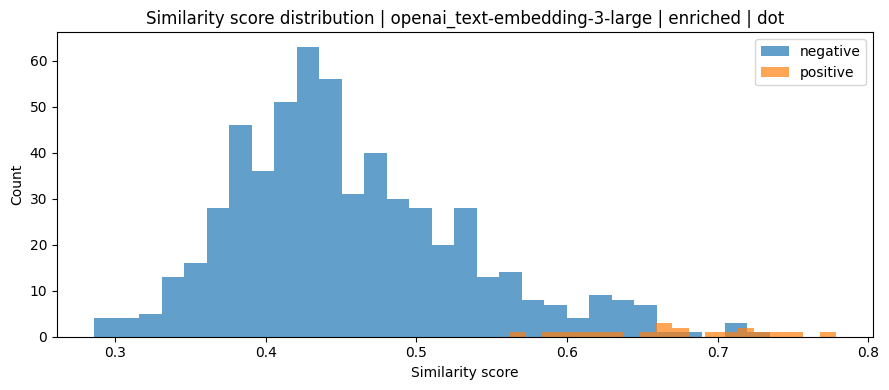

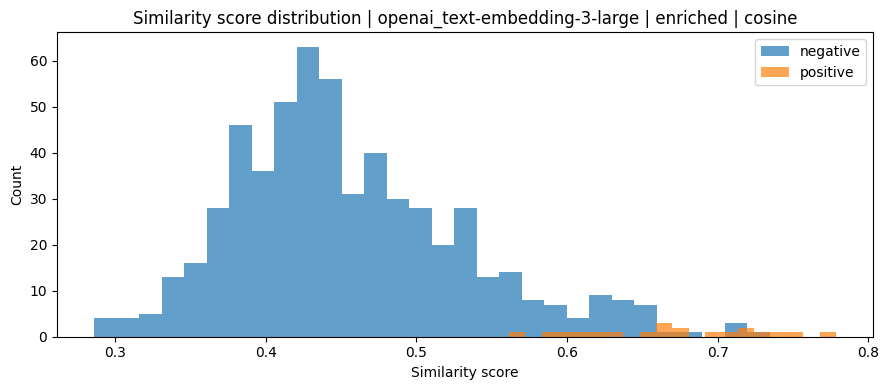

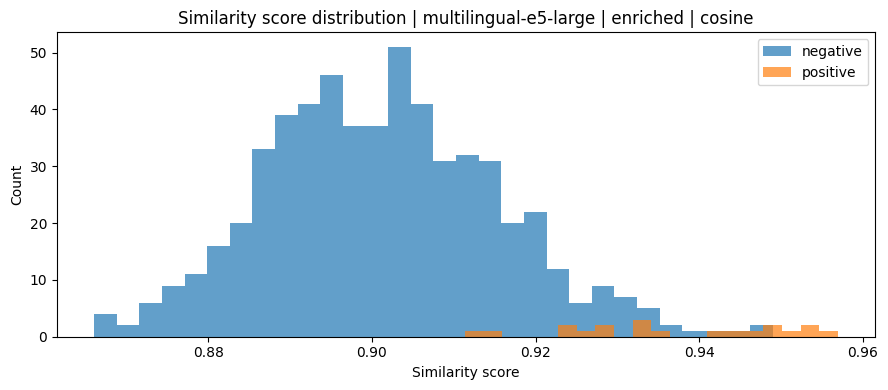

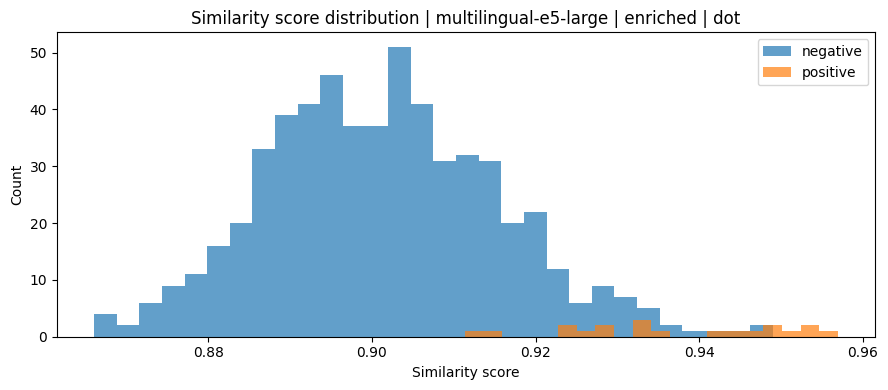

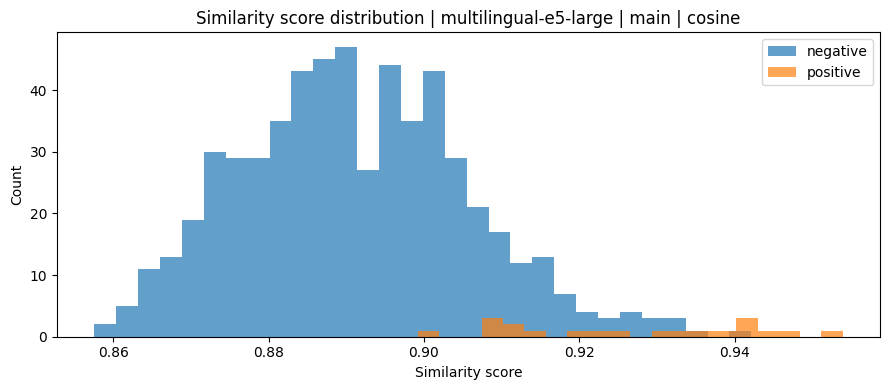

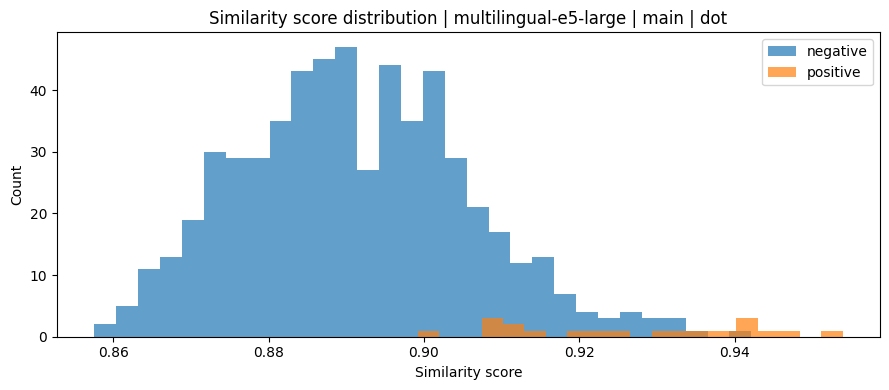

In [34]:
# Cell 25 - Plot score distributions for the top 6 configurations by Average Precision

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]
    similarity_metric = cfg["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    pos_scores = plot_df.loc[plot_df["overlap_label_binary"] == 1, "similarity_score"]
    neg_scores = plot_df.loc[plot_df["overlap_label_binary"] == 0, "similarity_score"]

    plt.figure(figsize=(9, 4))
    plt.hist(neg_scores, bins=30, alpha=0.7, label="negative")
    plt.hist(pos_scores, bins=20, alpha=0.7, label="positive")
    plt.title(f"Similarity score distribution | {model_name} | {text_variant} | {similarity_metric}")
    plt.xlabel("Similarity score")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"hist_{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}.png",
        dpi=150
    )
    plt.show()

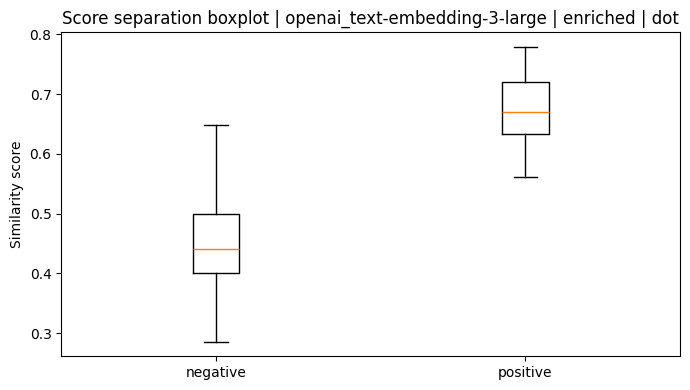

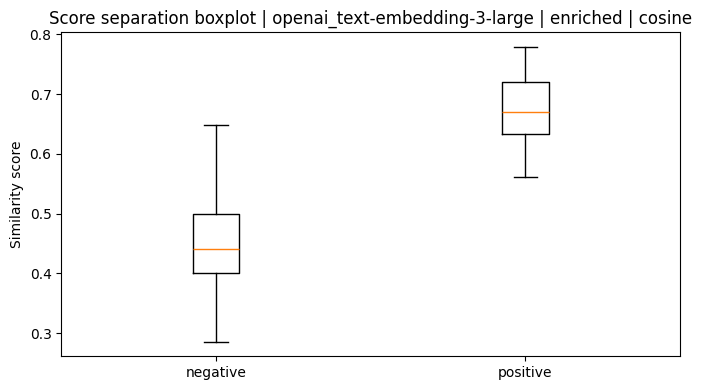

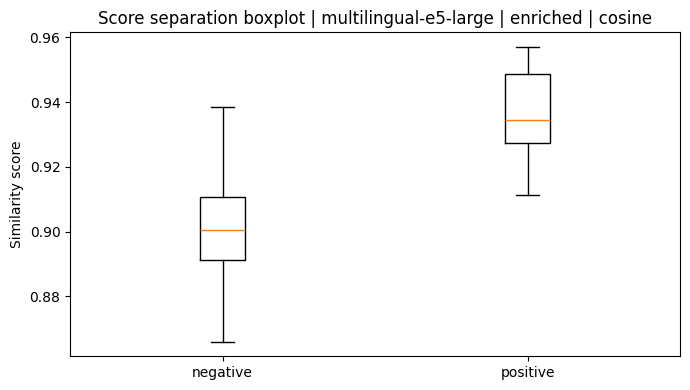

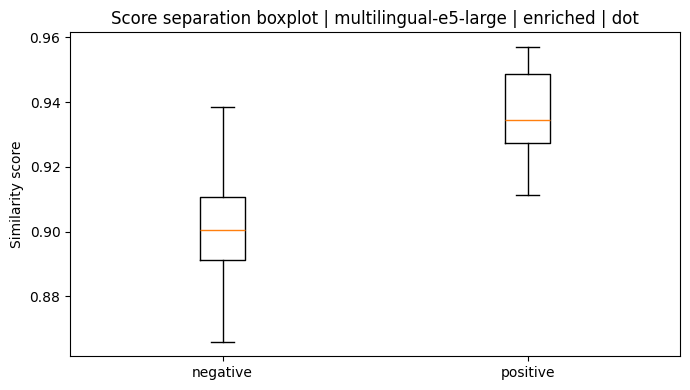

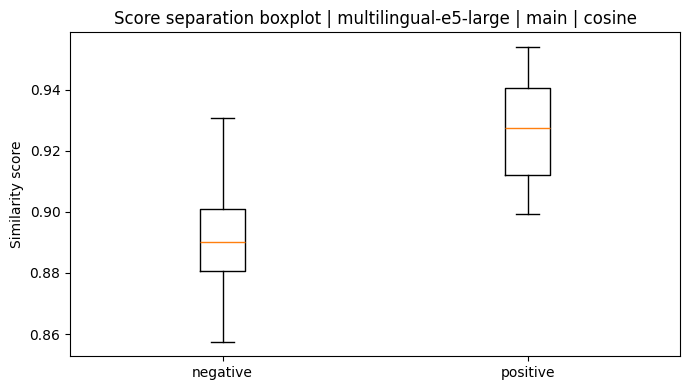

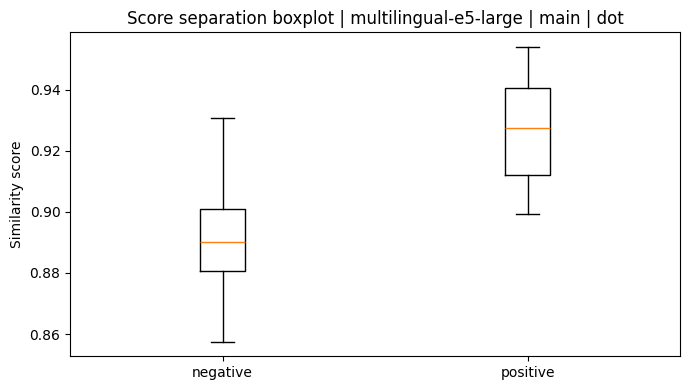

In [35]:
# Cell 26 - Boxplot comparison for the top 6 configurations

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]
    similarity_metric = cfg["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    neg_scores = plot_df.loc[plot_df["overlap_label_binary"] == 0, "similarity_score"].tolist()
    pos_scores = plot_df.loc[plot_df["overlap_label_binary"] == 1, "similarity_score"].tolist()

    plt.figure(figsize=(7, 4))
    plt.boxplot([neg_scores, pos_scores], labels=["negative", "positive"], showfliers=False)
    plt.title(f"Score separation boxplot | {model_name} | {text_variant} | {similarity_metric}")
    plt.ylabel("Similarity score")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"boxplot_{slugify_name(model_name)}__{slugify_name(text_variant)}__{slugify_name(similarity_metric)}.png",
        dpi=150
    )
    plt.show()

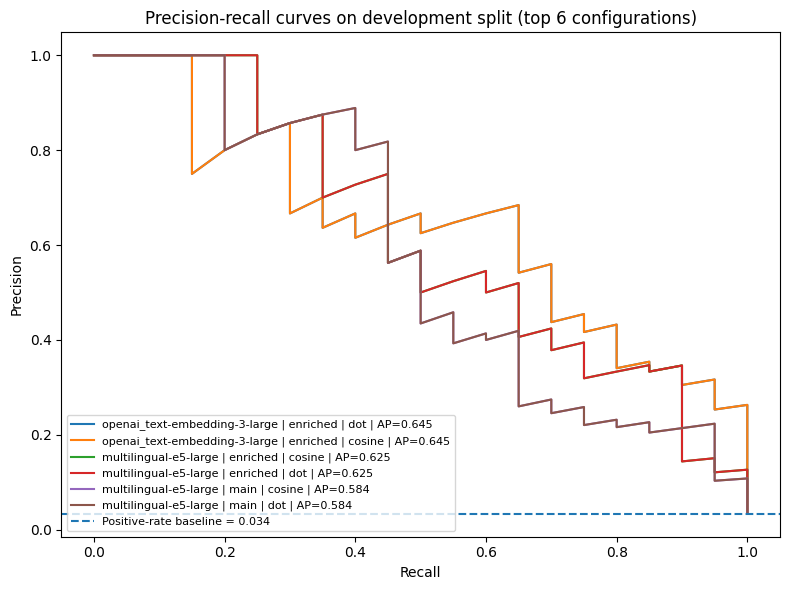

In [36]:
# Cell 27 - Precision-recall curves for the top 6 configurations

plt.figure(figsize=(8, 6))

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]
    similarity_metric = cfg["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    y_true = plot_df["overlap_label_binary"].to_numpy()
    y_score = plot_df["similarity_score"].to_numpy()

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.plot(
        recall_vals,
        precision_vals,
        label=f"{model_name} | {text_variant} | {similarity_metric} | AP={ap:.3f}"
    )

baseline_precision = benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev", "overlap_label_binary"].mean()
plt.axhline(y=baseline_precision, linestyle="--", label=f"Positive-rate baseline = {baseline_precision:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves on development split (top 6 configurations)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "precision_recall_curves_dev_top6.png", dpi=150)
plt.show()

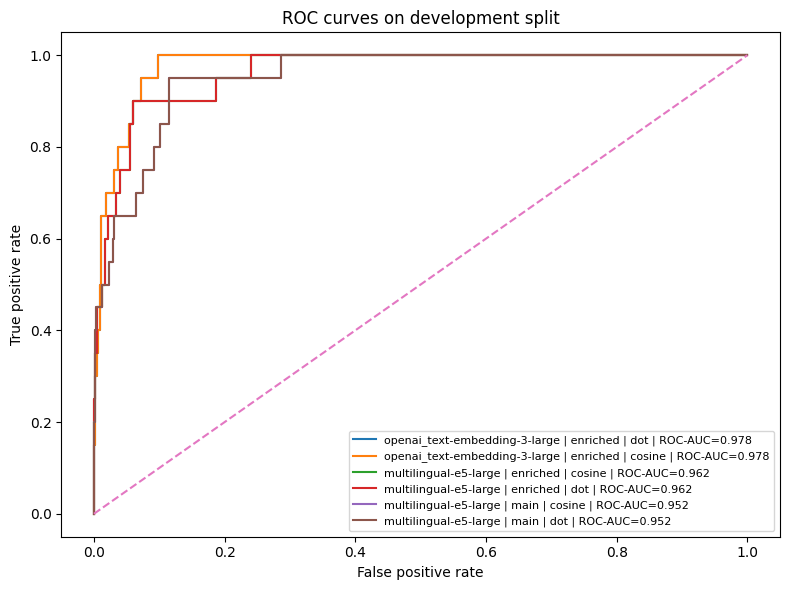

In [37]:
# Cell 28 - ROC curves for the top 6 configurations

plt.figure(figsize=(8, 6))

for cfg in top_configs:
    model_name = cfg["model_name"]
    text_variant = cfg["text_variant"]
    similarity_metric = cfg["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    y_true = plot_df["overlap_label_binary"].to_numpy()
    y_score = plot_df["similarity_score"].to_numpy()

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} | {text_variant} | {similarity_metric} | ROC-AUC={roc_auc:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on development split")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curves_dev_top6.png", dpi=150)
plt.show()

### Inspect top-ranked development pairs and hard false positives

A ranking benchmark should not be judged only by aggregate metrics.

This notebook inspects:
- highest-scoring development pairs overall
- highest-scoring negative pairs (hard false positives)

These cases help reveal where semantic similarity overgeneralizes.

In [38]:
# Cell 29 - Save and display top-ranked development pairs for each configuration

top_pair_rows = []

for (model_name, text_variant, similarity_metric), group_df in dev_scores_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    ranked_df = group_df.sort_values("similarity_score", ascending=False).head(15).copy()
    ranked_df["rank_within_config"] = range(1, len(ranked_df) + 1)
    top_pair_rows.append(ranked_df)

top_ranked_dev_pairs_df = pd.concat(top_pair_rows, ignore_index=True)
top_ranked_dev_pairs_df.to_csv(TOP_PAIRS_CSV_PATH, index=False, encoding="utf-8")

print("Saved top-ranked dev pairs to:", TOP_PAIRS_CSV_PATH)

display(
    top_ranked_dev_pairs_df[[
        "model_name",
        "text_variant",
        "similarity_metric",
        "rank_within_config",
        "pair_id",
        "course_name_1",
        "course_name_2",
        "overlap_label_binary",
        "similarity_score",
    ]].head(30)
)

Saved top-ranked dev pairs to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\top_ranked_dev_pairs_by_config.csv


,model_name,text_variant,similarity_metric,rank_within_config,pair_id,course_name_1,course_name_2,overlap_label_binary,similarity_score
0,bge-m3,enriched,cosine,1,TT00CD87__TT00CE11,Information Security Technologies,Data Security Controls,1,0.845275
1,bge-m3,enriched,cosine,2,TT00CD75__TT00CE25,Windows Basics,Windows Infrastructure,1,0.827366
2,bge-m3,enriched,cosine,3,TT00CD87__TT00CD88,Information Security Technologies,Hardening,1,0.826106
3,bge-m3,enriched,cosine,4,TT00CD86__TT00CD87,Cyber Security,Information Security Technologies,1,0.822235
4,bge-m3,enriched,cosine,5,TT00CD86__TT00CE08,Cyber Security,Basics of Cyber Security Exercises,0,0.821676
5,bge-m3,enriched,cosine,6,TT00CE05__TT00CE06,Data Analytics Project,Machine Learning Project,1,0.816466
6,bge-m3,enriched,cosine,7,TT00CD96__TT00CK80,Graphics Programming,Mathematical Basics of Graphics Programming,1,0.783150
7,bge-m3,enriched,cosine,8,TT00CD86__TT00CE07,Cyber Security,Cyber Security Management,0,0.781913
8,bge-m3,enriched,cosine,9,TT00CD86__TT00CE11,Cyber Security,Data Security Controls,1,0.781148
9,bge-m3,enriched,cosine,10,TT00CE07__TT00CE11,Cyber Security Management,Data Security Controls,0,0.779993


In [39]:
# Cell 30 - Hard false positives: highest-scoring negative pairs for each configuration

hard_false_positive_rows = []

for (model_name, text_variant, similarity_metric), group_df in dev_scores_df.groupby(
    ["model_name", "text_variant", "similarity_metric"]
):
    negatives_df = group_df[group_df["overlap_label_binary"] == 0].copy()
    hardest_df = negatives_df.sort_values("similarity_score", ascending=False).head(5).copy()
    hardest_df["hard_false_positive_rank"] = range(1, len(hardest_df) + 1)
    hard_false_positive_rows.append(hardest_df)

hard_false_positives_df = pd.concat(hard_false_positive_rows, ignore_index=True)
hard_false_positives_df.to_csv(HARD_FALSE_POSITIVES_CSV_PATH, index=False, encoding="utf-8")

print("Saved hard false positives to:", HARD_FALSE_POSITIVES_CSV_PATH)

display(
    hard_false_positives_df[[
        "model_name",
        "text_variant",
        "similarity_metric",
        "hard_false_positive_rank",
        "pair_id",
        "course_name_1",
        "course_name_2",
        "similarity_score",
    ]].head(30)
)

Saved hard false positives to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\hard_false_positives_dev_top5_by_config.csv


,model_name,text_variant,similarity_metric,hard_false_positive_rank,pair_id,course_name_1,course_name_2,similarity_score
0,bge-m3,enriched,cosine,1,TT00CD86__TT00CE08,Cyber Security,Basics of Cyber Security Exercises,0.821676
1,bge-m3,enriched,cosine,2,TT00CD86__TT00CE07,Cyber Security,Cyber Security Management,0.781913
2,bge-m3,enriched,cosine,3,TT00CE07__TT00CE11,Cyber Security Management,Data Security Controls,0.779993
3,bge-m3,enriched,cosine,4,TT00CD99__TT00CE00,Data Sources and Data Preprocessing,Data Analysis and Visualization,0.777157
4,bge-m3,enriched,cosine,5,TT00CD89__TT00CE09,Software Testing,Auditing and Penetration Testing,0.772359
5,bge-m3,enriched,dot,1,TT00CD86__TT00CE08,Cyber Security,Basics of Cyber Security Exercises,0.821676
6,bge-m3,enriched,dot,2,TT00CD86__TT00CE07,Cyber Security,Cyber Security Management,0.781913
7,bge-m3,enriched,dot,3,TT00CE07__TT00CE11,Cyber Security Management,Data Security Controls,0.779993
8,bge-m3,enriched,dot,4,TT00CD99__TT00CE00,Data Sources and Data Preprocessing,Data Analysis and Visualization,0.777157
9,bge-m3,enriched,dot,5,TT00CD89__TT00CE09,Software Testing,Auditing and Penetration Testing,0.772359


### Select shortlist candidates for Notebook 04

Notebook 04 should focus on a manageable set of strong candidates.

This shortlist keeps:
- strong dense candidates
- at least one `main`-variant comparison
- the TF-IDF lexical baseline
- avoids redundant cosine/dot duplicates when they are empirically identical for ranking

In [40]:
# Cell 31 - Build shortlist for Notebook 04

shortlist_source_df = benchmark_summary_dev_df.copy()

# When cosine and dot are tied, prefer cosine for interpretability
shortlist_source_df["metric_preference_rank"] = np.where(
    shortlist_source_df["similarity_metric"] == "cosine", 0, 1
)

best_per_model_df = (
    shortlist_source_df
    .sort_values(
        ["model_name", "average_precision", "roc_auc", "metric_preference_rank"],
        ascending=[True, False, False, True]
    )
    .groupby("model_name", as_index=False)
    .head(1)
    .copy()
)

best_main_df = shortlist_source_df[shortlist_source_df["text_variant"] == "main"].copy()
best_main_row = None
if not best_main_df.empty:
    best_main_row = best_main_df.sort_values(
        ["average_precision", "roc_auc", "metric_preference_rank"],
        ascending=[False, False, True]
    ).head(1)

shortlist_df = best_per_model_df.copy()

if best_main_row is not None:
    candidate_model = best_main_row.iloc[0]["model_name"]
    candidate_variant = best_main_row.iloc[0]["text_variant"]
    candidate_metric = best_main_row.iloc[0]["similarity_metric"]

    already_present = (
        (shortlist_df["model_name"] == candidate_model) &
        (shortlist_df["text_variant"] == candidate_variant) &
        (shortlist_df["similarity_metric"] == candidate_metric)
    ).any()

    if not already_present:
        shortlist_df = pd.concat([shortlist_df, best_main_row], ignore_index=True)

# Always keep TF-IDF cosine baseline, even if not top-ranked
tfidf_cosine_df = shortlist_source_df[
    (shortlist_source_df["model_name"] == "tfidf") &
    (shortlist_source_df["similarity_metric"] == "cosine")
].sort_values(["average_precision", "roc_auc"], ascending=[False, False]).head(1)

if not tfidf_cosine_df.empty:
    tfidf_row = tfidf_cosine_df.iloc[0]
    tfidf_already_present = (
        (shortlist_df["model_name"] == tfidf_row["model_name"]) &
        (shortlist_df["text_variant"] == tfidf_row["text_variant"]) &
        (shortlist_df["similarity_metric"] == tfidf_row["similarity_metric"])
    ).any()

    if not tfidf_already_present:
        shortlist_df = pd.concat([shortlist_df, tfidf_cosine_df], ignore_index=True)

shortlist_df = shortlist_df.sort_values(
    ["average_precision", "roc_auc", "metric_preference_rank"],
    ascending=[False, False, True]
).reset_index(drop=True)

SHORTLIST_LIMIT = 6
shortlist_df = shortlist_df.head(SHORTLIST_LIMIT).copy()
shortlist_df["shortlist_rank"] = range(1, len(shortlist_df) + 1)

shortlist_df.to_csv(SHORTLIST_CSV_PATH, index=False, encoding="utf-8")

print("Saved shortlist to:", SHORTLIST_CSV_PATH)
display(shortlist_df)

Saved shortlist to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\tables\benchmark\shortlist_for_notebook_04.csv


,model_name,text_variant,similarity_metric,pair_count_dev,positive_count_dev,negative_count_dev,positive_rate_dev,similarity_mean_positive,similarity_mean_negative,similarity_mean_gap,similarity_median_positive,similarity_median_negative,similarity_median_gap,average_precision,ap_lift_vs_prevalence,roc_auc,metric_preference_rank,shortlist_rank
0,openai_text-embedding-3-large,enriched,cosine,595,20,575,0.033613,0.672488,0.455197,0.217292,0.669671,0.440653,0.229018,0.644586,19.176442,0.978261,0,1
1,multilingual-e5-large,enriched,cosine,595,20,575,0.033613,0.936979,0.901361,0.035617,0.934471,0.900470,0.034001,0.625485,18.608173,0.962435,0,2
2,multilingual-e5-large,main,cosine,595,20,575,0.033613,0.926948,0.891084,0.035864,0.927504,0.890032,0.037472,0.584493,17.388679,0.952261,0,3
3,bge-m3,enriched,cosine,595,20,575,0.033613,0.751666,0.622171,0.129496,0.738406,0.617110,0.121296,0.560155,16.664612,0.954522,0,4
4,multilingual-e5-base,enriched,cosine,595,20,575,0.033613,0.932840,0.901833,0.031007,0.933102,0.901464,0.031639,0.503028,14.965086,0.933826,0,5
5,tfidf,enriched,cosine,595,20,575,0.033613,0.284691,0.126054,0.158637,0.251471,0.119261,0.132210,0.479716,14.271547,0.918522,0,6


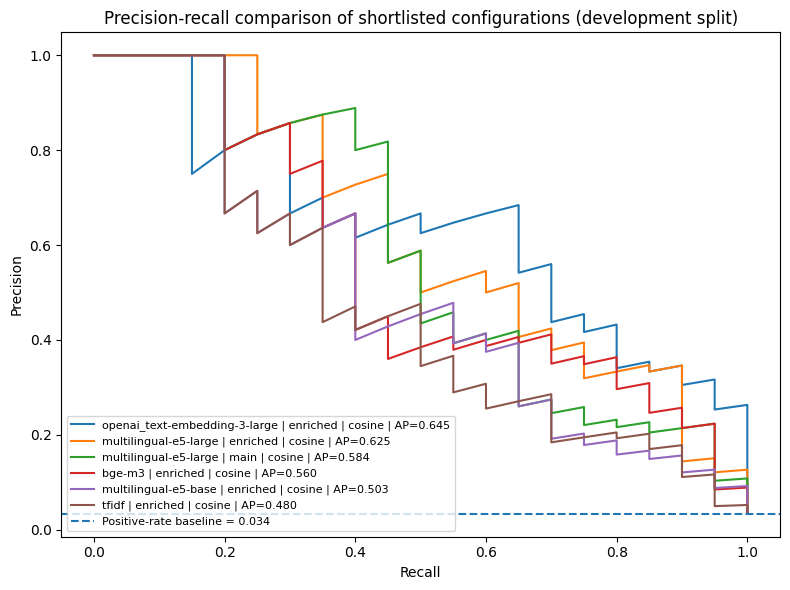

Saved shortlist PR comparison plot to: C:\Users\user\Downloads\curriculum-overlap-poc\reports\figures\benchmark\precision_recall_curves_dev_shortlist.png


In [41]:
# Cell 32 - Final comparison plot for shortlisted configurations

comparison_df = shortlist_df[["model_name", "text_variant", "similarity_metric"]].drop_duplicates().copy()

plt.figure(figsize=(8, 6))

for _, row in comparison_df.iterrows():
    model_name = row["model_name"]
    text_variant = row["text_variant"]
    similarity_metric = row["similarity_metric"]

    plot_df = dev_scores_df[
        (dev_scores_df["model_name"] == model_name) &
        (dev_scores_df["text_variant"] == text_variant) &
        (dev_scores_df["similarity_metric"] == similarity_metric)
    ].copy()

    y_true = plot_df["overlap_label_binary"].to_numpy()
    y_score = plot_df["similarity_score"].to_numpy()

    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.plot(
        recall_vals,
        precision_vals,
        label=f"{model_name} | {text_variant} | {similarity_metric} | AP={ap:.3f}"
    )

baseline_precision = benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev", "overlap_label_binary"].mean()
plt.axhline(y=baseline_precision, linestyle="--", label=f"Positive-rate baseline = {baseline_precision:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall comparison of shortlisted configurations (development split)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()

shortlist_pr_plot_path = FIGURES_DIR / "precision_recall_curves_dev_shortlist.png"
plt.savefig(shortlist_pr_plot_path, dpi=150)
plt.show()

print("Saved shortlist PR comparison plot to:", shortlist_pr_plot_path)

### Interpretation guide for thesis writing

When writing up Notebook 03 in the thesis, the main interpretation should focus on:

- whether semantic models outperform the TF-IDF baseline
- whether `main` or `enriched` produces the clearest separation
- whether cosine and dot produce meaningfully different results
- whether the best method produces practically useful score separation
- whether hard false positives reveal consistent semantic overgeneralization patterns

Important:
- high ROC-AUC alone is not enough
- raw accuracy is not meaningful under strong class imbalance
- final threshold tuning belongs to Notebook 04
- Average Precision and AP lift above prevalence are the most useful ranking summaries here
- similarity-gap columns are practically useful because very small positive-vs-negative score gaps can make threshold selection fragile

In [43]:
# Cell 33 - Winner summary for Notebook 04

winner_source_df = benchmark_summary_dev_df.copy()
winner_source_df["metric_preference_rank"] = np.where(
    winner_source_df["similarity_metric"] == "cosine", 0, 1
)

best_row = winner_source_df.sort_values(
    ["average_precision", "roc_auc", "metric_preference_rank"],
    ascending=[False, False, True]
).iloc[0]

dev_pair_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev"].shape[0])
dev_positive_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "dev", "overlap_label_binary"].sum())
test_pair_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "test"].shape[0])
test_positive_count = int(benchmark_pairs_df.loc[benchmark_pairs_df["split"] == "test", "overlap_label_binary"].sum())

print("Best development configuration overall:")
print(f"  Model: {best_row['model_name']}")
print(f"  Text variant: {best_row['text_variant']}")
print(f"  Similarity metric: {best_row['similarity_metric']}")
print(f"  Average Precision: {best_row['average_precision']:.4f}")
print(f"  AP lift vs prevalence: {best_row['ap_lift_vs_prevalence']:.2f}x")
print(f"  ROC-AUC: {best_row['roc_auc']:.4f}")
print(f"  Mean similarity gap: {best_row['similarity_mean_gap']:.4f}")
print(f"  Median similarity gap: {best_row['similarity_median_gap']:.4f}")
print()

print("Evaluation context:")
print(f"  Dev pairs: {dev_pair_count}")
print(f"  Dev positives: {dev_positive_count}")
print(f"  Test pairs: {test_pair_count}")
print(f"  Test positives: {test_positive_count}")
print()

print("Interpretation:")
print(
    "For dense models in this dataset, cosine and dot are effectively identical because raw embedding norms are nearly constant. "
    "Therefore cosine is preferred for interpretability when the ranking results are tied."
)
print()
print("Notebook 04 should begin by evaluating the shortlisted configurations with tuned thresholds.")
print("Interpret final test metrics cautiously, because the test split still contains only a small number of positive pairs.")

Best development configuration overall:
  Model: openai_text-embedding-3-large
  Text variant: enriched
  Similarity metric: cosine
  Average Precision: 0.6446
  AP lift vs prevalence: 19.18x
  ROC-AUC: 0.9783
  Mean similarity gap: 0.2173
  Median similarity gap: 0.2290

Evaluation context:
  Dev pairs: 595
  Dev positives: 20
  Test pairs: 105
  Test positives: 5

Interpretation:
For dense models in this dataset, cosine and dot are effectively identical because raw embedding norms are nearly constant. Therefore cosine is preferred for interpretability when the ranking results are tied.

Notebook 04 should begin by evaluating the shortlisted configurations with tuned thresholds.
Interpret final test metrics cautiously, because the test split still contains only a small number of positive pairs.


## Final note

Notebook 03 benchmarks **score quality** across lexical and dense embedding methods using a **course-level** development/test split.

### What this notebook does well
- aligns evaluation more closely with held-out generalization than a pair-level split
- compares multiple text variants instead of assuming one representation is best
- compares both cosine similarity and dot product
- includes a lexical baseline for context
- separates model screening from later threshold selection
- saves reusable benchmark artifacts for Notebook 04
- includes both quantitative ranking metrics and qualitative error inspection

### Why this design is appropriate
This thesis is not only about producing a similarity score. It is about understanding which representation, embedding model, and similarity metric produce scores that are most useful for overlap detection under realistic class imbalance. That is why Notebook 03 focuses on ranking quality, score separation, and error patterns rather than final threshold tuning.

### Important limitations
- The dataset is small and overlap pairs are rare.
- The course-level split is constructed using a constrained search to preserve a minimally usable number of positive pairs in both dev and test.
- Some labeled positive pairs are excluded from both development and test evaluation because mixed pairs are discarded.
- Even after improvement, the test split still contains only a small number of positive pairs, so Notebook 04 threshold metrics should be interpreted cautiously.
- If cosine and dot produce effectively identical rankings for dense models, that should be interpreted as an empirical property of the embedding norms in this dataset rather than as a benchmarking failure.

Notebook 04 will use the shortlisted configurations from this notebook to choose and evaluate operating thresholds more carefully.